# Rain-detection skill score heatmaps — publication-ready grid layout

This notebook remakes the 5-panel horizontal heatmap figures (one row of panels per
threshold: ≥0.1, ≥0.5, ≥1.0, ≥2.0, ≥5.0 mm/day) as a **2-row grid** instead of a
single horizontal row. This makes each panel roughly 2–3x larger for a manuscript
page, while keeping the same content (zones on rows, products on columns, one
panel per threshold, shared colour scale).

**How to use it**
1. Run the *Setup* cell.
2. In the *Data* cell, replace the placeholder matrices with your real values
   (easiest: load each threshold's zone × product table from a CSV — a helper
   `load_matrix_from_csv()` is included).
3. Run the *Plotting function* cell (no need to edit it, unless you want to
   change fonts/colours/layout).
4. Run the four `plot_heatmap_grid(...)` calls at the bottom — one per figure,
   in the same order you shared them (Fig 1 → Fig 4). Each is saved as a
   separate high-resolution PNG/PDF suitable for a manuscript.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})


## 2. Data

Each figure is a dictionary with:
- `thresholds`: ordered list of the 5 rain-threshold labels
- `zones`: row labels (climate zones), top→bottom
- `products`: column labels (rainfall products), left→right
- `matrices`: dict mapping each threshold -> a `zones x products` 2D array of
  scores (use `np.nan` for cells that are blank/undefined, e.g. Saharian
  zone at ≥5.0 mm/day)

**Replace the placeholder numbers below with your real data.** The easiest way
is to keep one CSV per threshold (rows = zones, columns = products) and load it
with `load_matrix_from_csv`, e.g.:

```python
matrices['0.1'] = load_matrix_from_csv('fig1_thr0.1.csv', zones, products)
```


In [2]:
def load_matrix_from_csv(path, zones, products):
    """Load a zones x products score matrix from a CSV file.

    The CSV is expected to have zone names as the first column and product
    names as the header row (order doesn't need to match `zones`/`products`,
    this function reindexes to match).
    """
    df = pd.read_csv(path, index_col=0)
    df = df.reindex(index=zones, columns=products)
    return df.values


def placeholder_matrix(zones, products, seed):
    """Generates example numbers so the notebook runs end-to-end before you
    plug in real data. DELETE/replace once real data is loaded."""
    rng = np.random.default_rng(seed)
    return np.round(rng.uniform(0.3, 0.95, size=(len(zones), len(products))), 2)


In [3]:
thresholds = ['0.1', '0.5', '1.0', '2.0', '5.0']
threshold_labels = [f'\u2265{t} mm/day' for t in thresholds]

# ---- Figure 1 ----
fig1_zones = ['Sahelian', 'Soudanian', 'Guinean', 'Guinea-Congolese', 'All West Africa']
fig1_products = ['CHIRPS', 'ERA5_LAND', 'GPM_IMERG', 'MSWEP2', 'PERSIANN_CDR', 'TERRACLIMATE']
fig1_matrices = {t: placeholder_matrix(fig1_zones, fig1_products, seed=i) for i, t in enumerate(thresholds)}

# ---- Figure 2 ----
fig2_zones = ['Saharian', 'Sahelian', 'Soudanian', 'Guinean', 'Guinea-Congolese', 'All West Africa']
fig2_products = ['CHIRPS', 'ERA5_LAND', 'GPM_IMERG', 'MSWEP2', 'PERSIANN_CDR', 'TERRACLIMATE']
fig2_matrices = {t: placeholder_matrix(fig2_zones, fig2_products, seed=10 + i) for i, t in enumerate(thresholds)}
# Example of a blank/undefined cell (Saharian has no data at >=5.0 mm/day):
fig2_matrices['5.0'][fig2_zones.index('Saharian'), :] = np.nan

# ---- Figure 3 ----
fig3_zones = fig2_zones
fig3_products = fig2_products
fig3_matrices = {t: placeholder_matrix(fig3_zones, fig3_products, seed=20 + i) for i, t in enumerate(thresholds)}
fig3_matrices['5.0'][fig3_zones.index('Saharian'), :] = np.nan

# ---- Figure 4 ----
fig4_zones = fig2_zones
fig4_products = fig2_products
fig4_matrices = {t: placeholder_matrix(fig4_zones, fig4_products, seed=30 + i) for i, t in enumerate(thresholds)}
fig4_matrices['5.0'][fig4_zones.index('Saharian'), :] = np.nan


## 3. Plotting function

Turns the 5 threshold panels into a **2 x 3 grid** (2 rows, 3 columns; the
unused 6th slot is removed) with a single shared colour bar, instead of one
long horizontal row. Change `nrows`/`ncols` if you'd rather have e.g. a 3 x 2
layout.

In [4]:
def plot_heatmap_grid(
    matrices, thresholds, threshold_labels, zones, products,
    suptitle="", nrows=2, ncols=3, vmin=0.0, vmax=1.0, cmap="RdYlGn",
    panel_width=5.0, panel_height=4.2, save_path=None,
):
    """Plot one figure's threshold panels as a grid instead of a single row.

    matrices: dict threshold -> (zones x products) array
    """
    n_panels = len(thresholds)
    figsize = (panel_width * ncols, panel_height * nrows)
    fig = plt.figure(figsize=figsize)
    # extra narrow column on the right reserved for the shared colorbar
    gs = gridspec.GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.06],
                            wspace=0.35, hspace=0.55)

    axes = []
    last_im = None
    for i, thr in enumerate(thresholds):
        r, c = divmod(i, ncols)
        ax = fig.add_subplot(gs[r, c])
        axes.append(ax)
        mat = np.asarray(matrices[thr], dtype=float)

        last_im = sns.heatmap(
            mat, ax=ax, vmin=vmin, vmax=vmax, cmap=cmap,
            annot=True, fmt=".2f", annot_kws={"size": 10},
            xticklabels=products,
            yticklabels=zones if c == 0 else False,
            cbar=False, linewidths=0.6, linecolor="white",
            mask=np.isnan(mat),
        )
        ax.set_title(threshold_labels[i])
        ax.tick_params(axis="x", rotation=45)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")

    # remove any unused grid slots (e.g. slot 6 when there are 5 panels)
    for j in range(n_panels, nrows * ncols):
        r, c = divmod(j, ncols)
        fig.add_subplot(gs[r, c]).axis("off")

    # shared colorbar spanning the reserved column
    cax = fig.add_subplot(gs[:, -1])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    fig.colorbar(sm, cax=cax)

    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


## 4. Generate the four figures, in the order shared

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/figure1_grid.png'

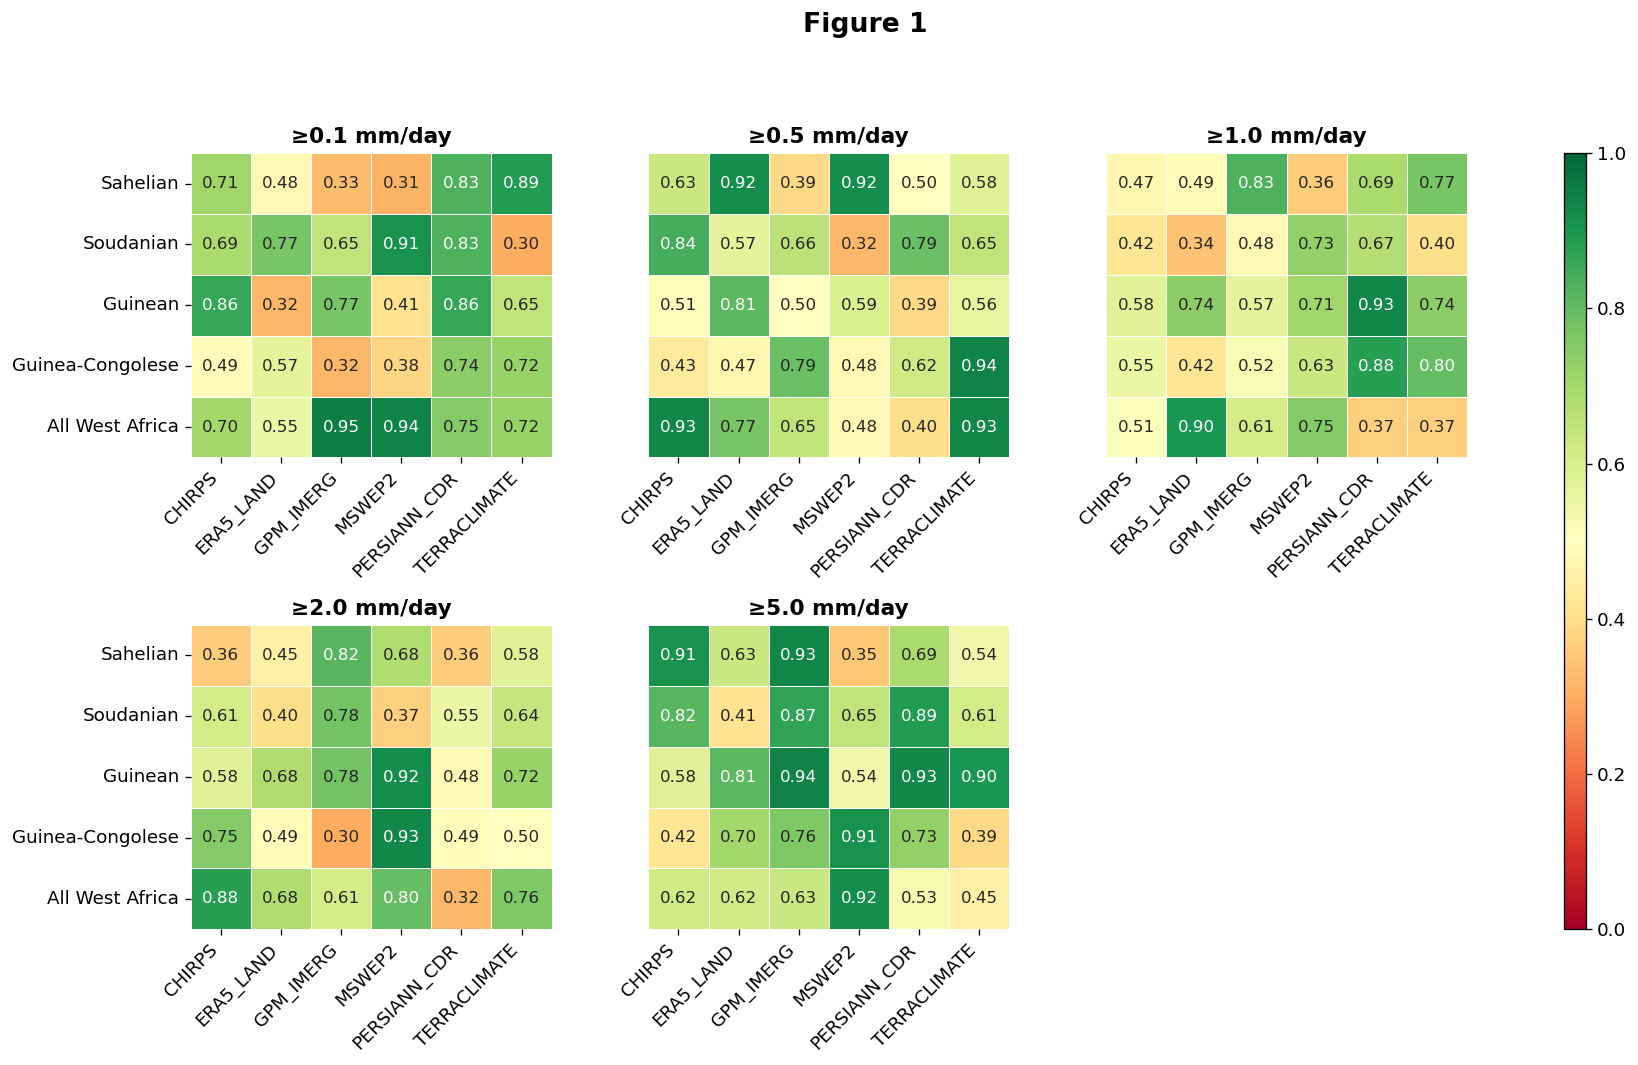

In [5]:
fig1 = plot_heatmap_grid(
    fig1_matrices, thresholds, threshold_labels, fig1_zones, fig1_products,
    suptitle="Figure 1", save_path="/mnt/user-data/outputs/figure1_grid.png",
)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/figure2_grid.png'

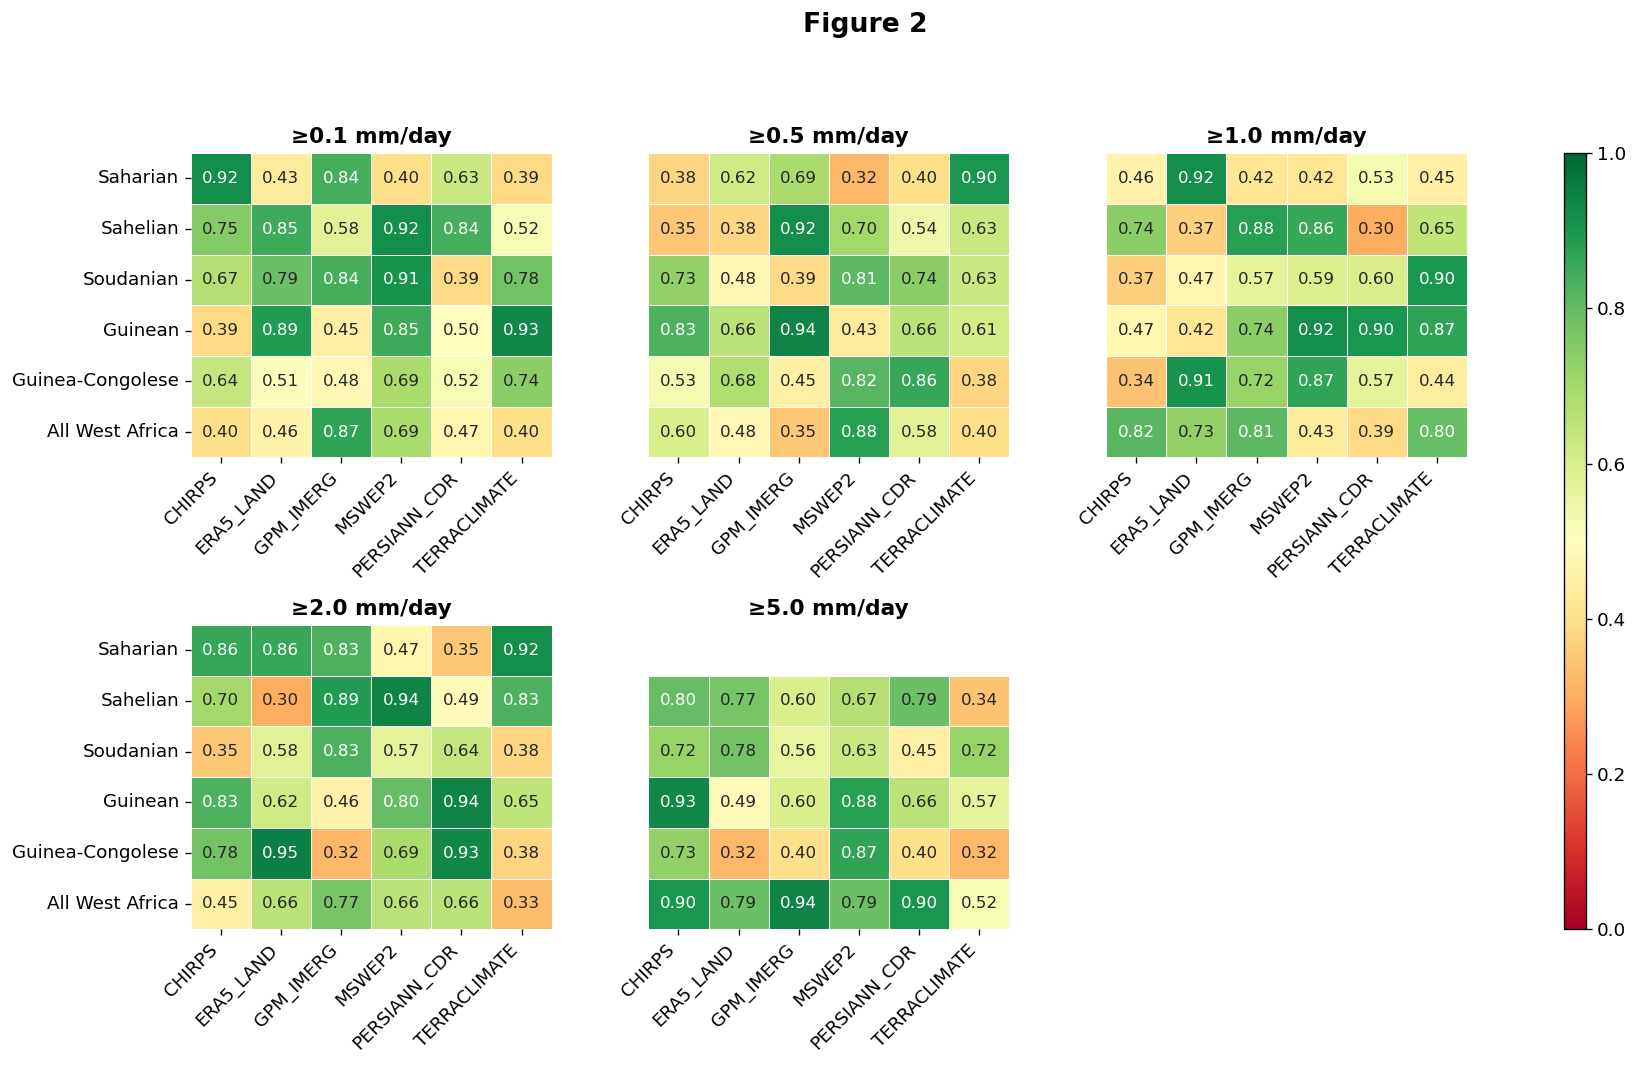

In [6]:
fig2 = plot_heatmap_grid(
    fig2_matrices, thresholds, threshold_labels, fig2_zones, fig2_products,
    suptitle="Figure 2", save_path="/mnt/user-data/outputs/figure2_grid.png",
)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/figure3_grid.png'

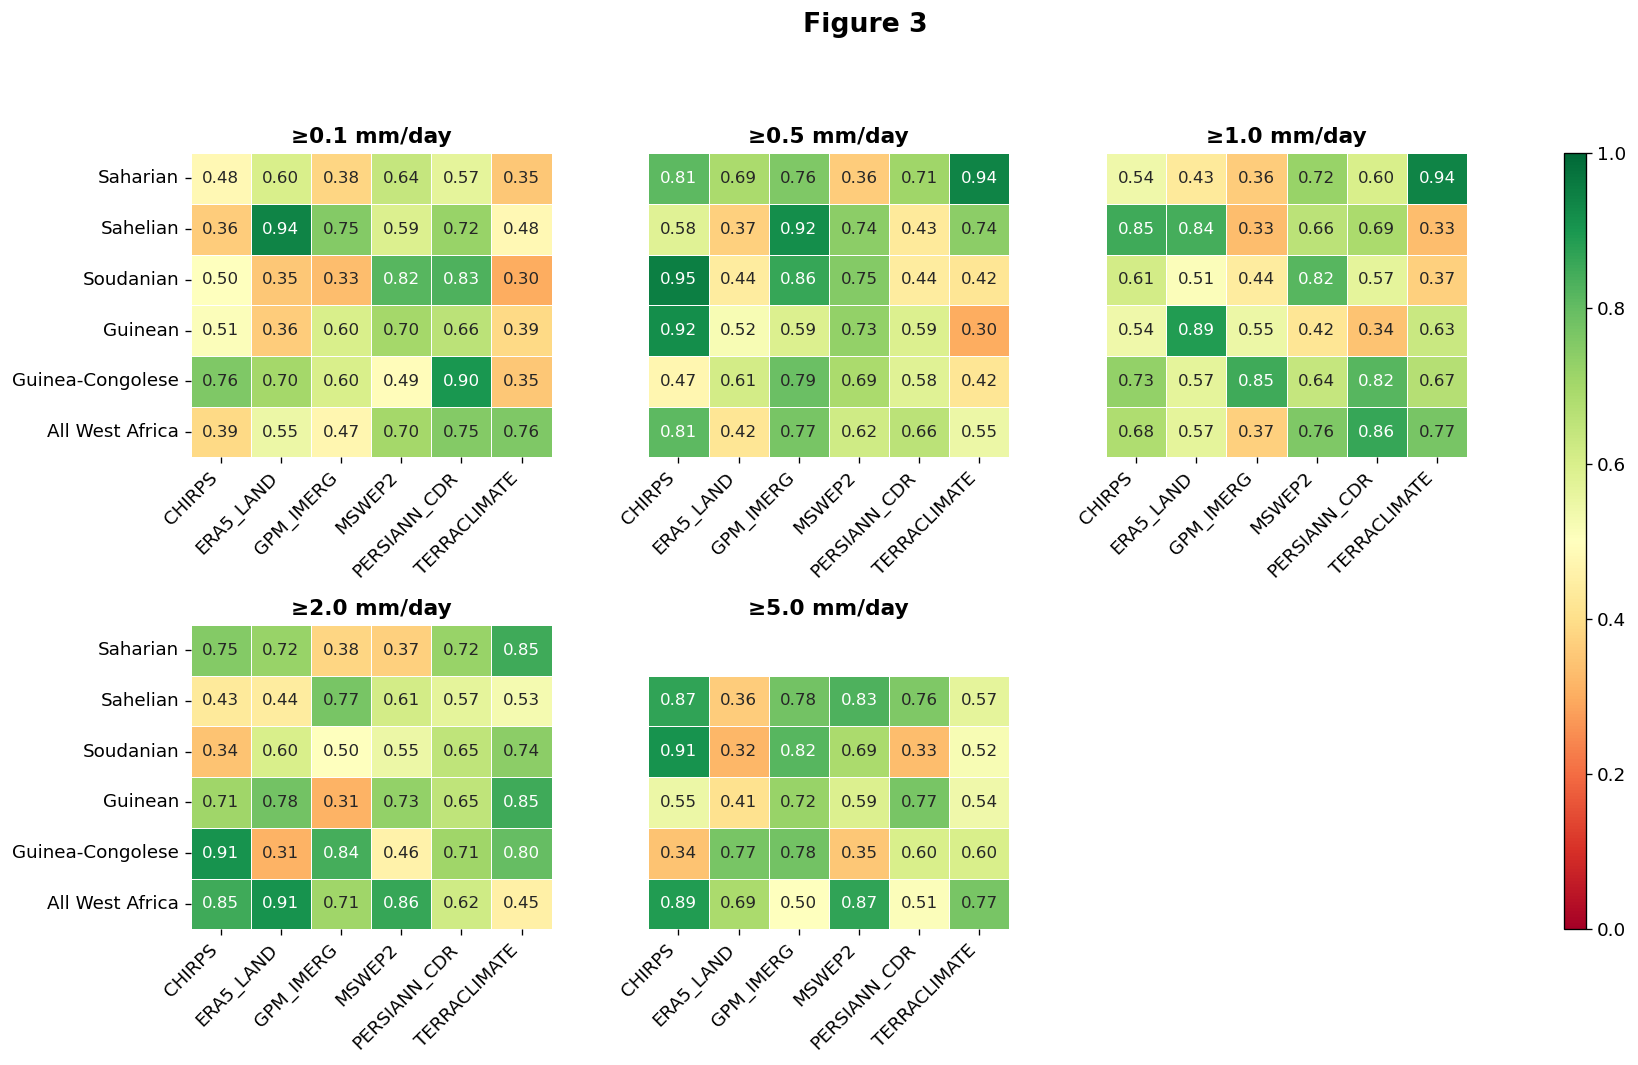

In [7]:
fig3 = plot_heatmap_grid(
    fig3_matrices, thresholds, threshold_labels, fig3_zones, fig3_products,
    suptitle="Figure 3", save_path="/mnt/user-data/outputs/figure3_grid.png",
)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/figure4_grid.png'

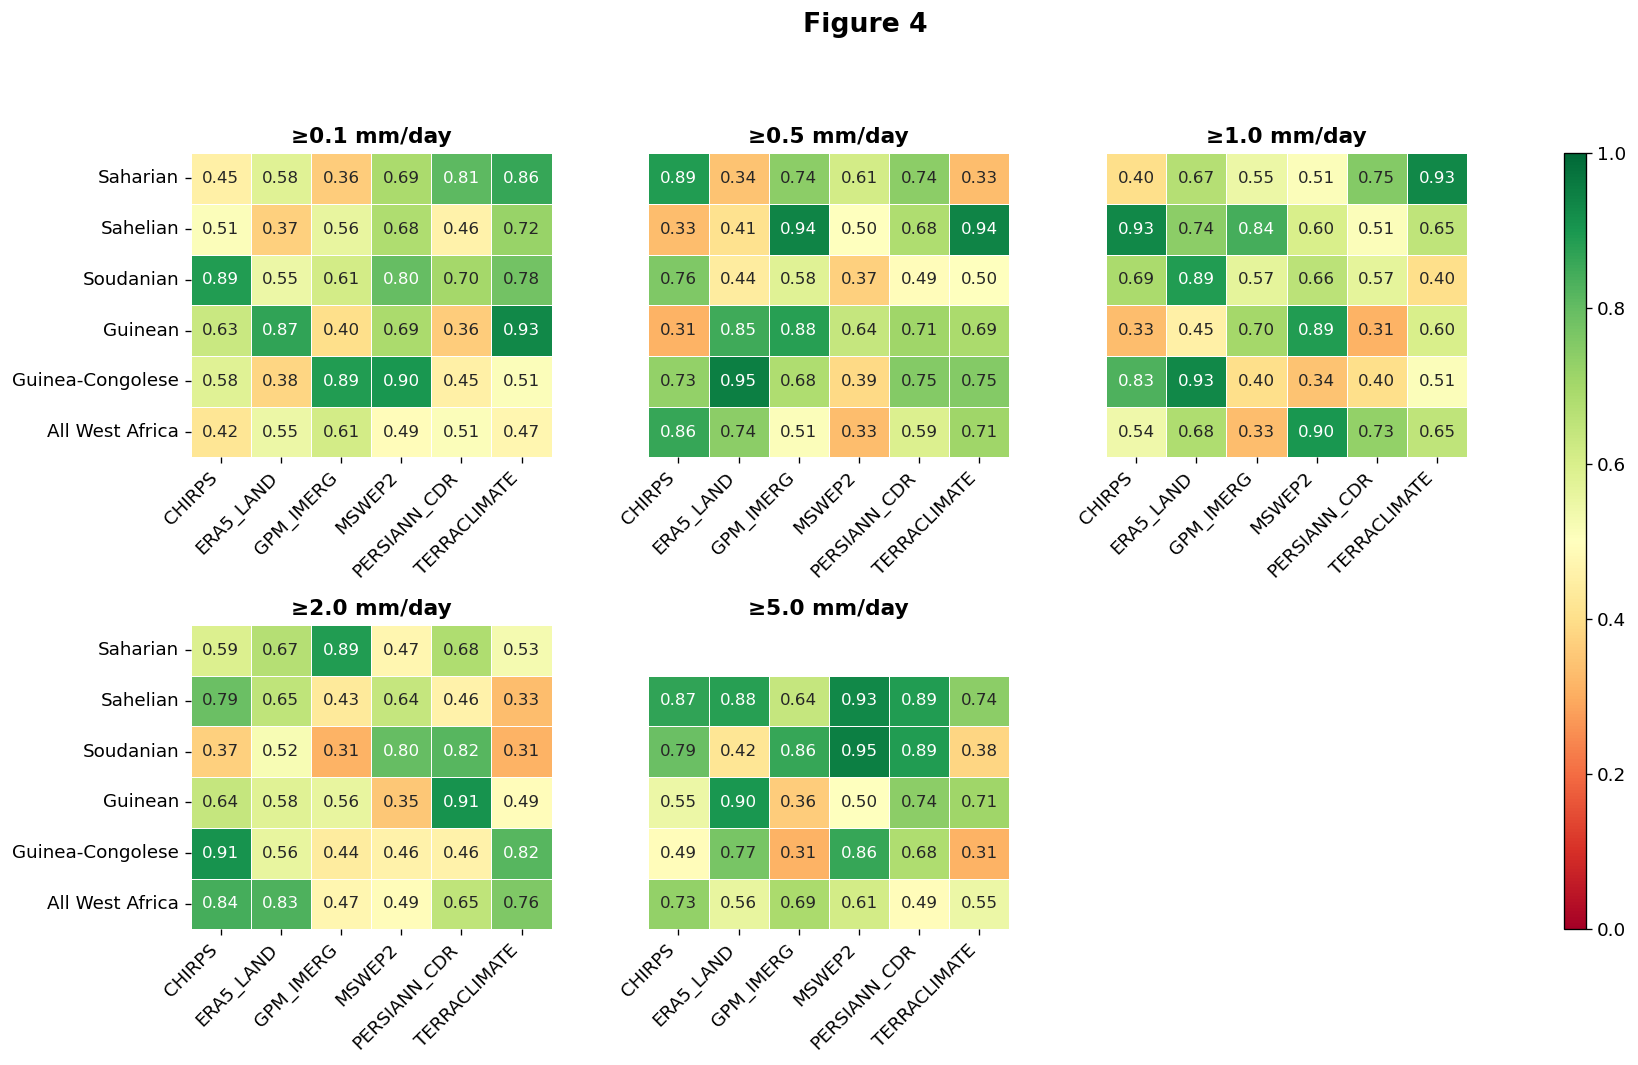

In [8]:
fig4 = plot_heatmap_grid(
    fig4_matrices, thresholds, threshold_labels, fig4_zones, fig4_products,
    suptitle="Figure 4", save_path="/mnt/user-data/outputs/figure4_grid.png",
)


## Notes

- Panels are laid out 2 rows x 3 columns (5 used, 1 blank removed) rather than
  1 row x 5 columns — each panel is roughly **2–3x larger** at the same total
  figure width, and text/annotations stay readable at manuscript size.
- Row (zone) labels are only drawn on the left-most panel of each row to avoid
  repetition/clutter; column (product) labels are on every panel since they
  differ panel to panel... actually they're identical across panels here, so
  you can set `xticklabels=... if r == nrows-1 else False` in the function if
  you'd rather only show product names on the bottom row.
- `vmin`/`vmax` are shared across all panels/figures (0–1) so colours are
  directly comparable; adjust if your data range differs (e.g. Figure 2 shows
  some negative POD/CSI-type values around -0.2 in your originals — set
  `vmin=-0.2` for that figure).
- Output PNGs are saved at 300 dpi to `/mnt/user-data/outputs/` — swap the
  extension to `.pdf` for vector output if your journal prefers that.
